In [35]:
# --- BLOQUE 1: IMPORTACIÓN DE LIBRERÍAS ---
# Usamos herramientas estándar para procesamiento (Pandas), 
# visualización (Seaborn) y aprendizaje no supervisado (Scikit-Learn).
import pandas as pd
import numpy as np
import re
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [36]:
# --- BLOQUE 2: CONFIGURACIÓN Y REPRODUCIBILIDAD ---
# Establecer una semilla (SEED) asegura que el muestreo 
# sea el mismo cada vez que se corra el código (Reproducibilidad).
SEED = 42
PATH_REVIEWS = "Office_Products.jsonl.gz"
PATH_META = "meta_Office_Products.jsonl.gz"
OUTPUT_FILE = "data/office_ready_1M.csv.gz"

# Crear carpeta de datos si no existe
import os
if not os.path.exists('data'): os.makedirs('data')

In [37]:
# --- BLOQUE 3: FUNCIONES DE PROCESAMIENTO ---
def clean_text_simple(text):
    """
    Limpia el texto eliminando ruido para que el modelo se enfoque en palabras clave.
    Mantenemos solo letras para reducir la dimensionalidad del vocabulario.
    """
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) # Eliminamos números y símbolos
    text = re.sub(r'\s+', ' ', text).strip() # Colapsamos espacios
    return text

In [38]:
def map_rating_to_class(rating):
    """
    Mapeo de estrellas a sentimiento. 
    Simplificamos el problema a 3 clases para mejorar 
    la interpretabilidad del negocio (Negativo, Neutral, Positivo).
    """
    if rating <= 2: return 0
    elif rating == 3: return 1
    else: return 2

In [39]:
# --- BLOQUE 4: CARGA DE METADATOS (DATA UNDERSTANDING) ---
print(" Cargando metadatos (Data Understanding)...")
# Cargamos solo columnas útiles para optimizar la RAM (16GB limit)
df_meta = pd.read_json(PATH_META, lines=True)
cols_meta = ['parent_asin', 'main_category', 'title', 'price']
df_meta = df_meta[cols_meta].dropna(subset=['parent_asin'])
print(f" Metadatos cargados: {len(df_meta):,} productos identificados.")

📦 Cargando metadatos (Data Understanding)...
✅ Metadatos cargados: 710,503 productos identificados.


In [40]:
# --- BLOQUE 5: EXTRACCIÓN Y FUSIÓN (DATA PREPARATION) ---
# Dado que el dataset tiene +12M de reseñas, aplicamos un 
# muestreo por fragmentos (chunks) para no saturar la RAM de la PC.
print(" Procesando reseñas por fragmentos...")
chunk_size = 500_000
sampled_list = []
rows_per_chunk = 75_000 # Cantidad controlada para llegar al millón

🔍 Procesando reseñas por fragmentos...


In [41]:
for chunk in tqdm(pd.read_json(PATH_REVIEWS, lines=True, chunksize=chunk_size)):
    # Selección de columnas críticas de interacción
    subset = chunk[['parent_asin', 'rating', 'text', 'helpful_vote']]
    
    # Inner Join: Solo mantenemos reseñas cuyos productos existen en metadatos
    merged_chunk = pd.merge(subset, df_meta, on='parent_asin', how='inner')
    
    if not merged_chunk.empty:
        n = min(len(merged_chunk), rows_per_chunk)
        sampled_list.append(merged_chunk.sample(n=n, random_state=SEED))
    
    del chunk, subset, merged_chunk
    gc.collect() # Forzamos limpieza de RAM

26it [05:11, 11.98s/it]


In [42]:
df_all = pd.concat(sampled_list, ignore_index=True)
print(f" Dataset preliminar unificado: {len(df_all):,} filas.")

✅ Dataset preliminar unificado: 1,950,000 filas.


In [47]:
# --- BLOQUE 6: BALANCEO ESTRATIFICADO ---
# Evitamos errores de índice de Pandas usando extracción manual por clase.
# Esto garantiza que tengamos exactamente la misma cantidad de ejemplos Neg, Neu y Pos.

print(" Iniciando balanceo de clases...")

# 1. Asegurar la columna de clase
df_all['sentiment_class'] = df_all['rating'].apply(map_rating_to_class)

# 2. Definir muestras por clase
target_per_class = 333_333
final_list = []

# 3. Extraer muestras una por una (evita el error de KeyError: 'sentiment_class')
for sentiment in [0, 1, 2]:
    # Filtramos la clase
    df_subset = df_all[df_all['sentiment_class'] == sentiment]
    
    # Tomamos la muestra
    n_samples = min(len(df_subset), target_per_class)
    df_sampled = df_subset.sample(n=n_samples, random_state=SEED)
    
    final_list.append(df_sampled)
    print(f" Clase {sentiment}: {n_samples:,} muestras obtenidas.")

# 4. Unificar todo en el df_final
df_final = pd.concat(final_list, ignore_index=True)

# 5. Limpieza total de memoria
print(f" Total en dataset balanceado: {len(df_final):,}")
print(df_final['sentiment_class'].value_counts())

del df_all, final_list
gc.collect()

⚖️ Iniciando balanceo de clases...
✅ Clase 0: 296,923 muestras obtenidas.
✅ Clase 1: 121,088 muestras obtenidas.
✅ Clase 2: 333,333 muestras obtenidas.
📊 Total en dataset balanceado: 751,344
sentiment_class
2    333333
0    296923
1    121088
Name: count, dtype: int64


1926

In [48]:
# --- BLOQUE 7: INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING) ---
print(" Ejecutando limpieza NLP y métricas...")
df_final['text_cleaned'] = df_final['text'].apply(clean_text_simple)
df_final['text_length'] = df_final['text_cleaned'].str.split().str.len()

# Convertir precio a numérico eliminando el símbolo '$'
df_final['price_num'] = pd.to_numeric(
    df_final['price'].astype(str).str.replace(r'[$,]', '', regex=True), 
    errors='coerce'
).fillna(0)

🧹 Ejecutando limpieza NLP y métricas...


In [49]:
# --- BLOQUE 8: COMPONENTE NO SUPERVISADO (SEGMENTACIÓN / CLUSTERING) ---
# Requisito Guía Grupo 2: "Segmentar reseñas por características observables"
print(" Ejecutando Clustering (Aprendizaje No Supervisado)...")

# Tomamos una muestra para el clustering (por límites de RAM y tiempo)
df_cluster = df_final.sample(n=30000, random_state=SEED)
tfidf_cluster = TfidfVectorizer(max_features=1000, stop_words='english')
matrix_cluster = tfidf_cluster.fit_transform(df_cluster['text_cleaned'])

# K-Means para identificar 4 temas comunes en las reseñas de oficina
kmeans = KMeans(n_clusters=4, random_state=SEED, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(matrix_cluster)

# Reducción de dimensionalidad (PCA) para visualizar los clusters
pca = PCA(n_components=2)
coords = pca.fit_transform(matrix_cluster.toarray())
df_cluster['pca_1'] = coords[:, 0]
df_cluster['pca_2'] = coords[:, 1]

🧩 Ejecutando Clustering (Aprendizaje No Supervisado)...


C:\Users\mfjm0\AppData\Local\Temp\ipykernel_30916\2219422325.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_class', data=df_final, palette='magma')


Text(0.5, 1.0, 'Distribución de Clases (Balanceada)')

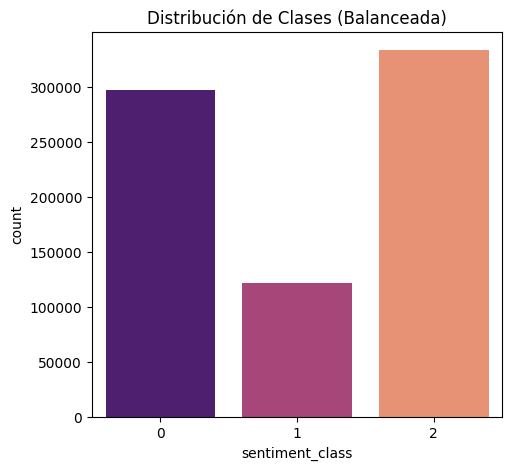

In [50]:
# --- BLOQUE 9: VISUALIZACIONES (EDA - DATA UNDERSTANDING) ---
plt.figure(figsize=(18, 5))

# 1. Distribución de Sentimiento
plt.subplot(1, 3, 1)
sns.countplot(x='sentiment_class', data=df_final, palette='magma')
plt.title('Distribución de Clases (Balanceada)')

Text(0.5, 1.0, 'Longitud de Reseña por Clase')

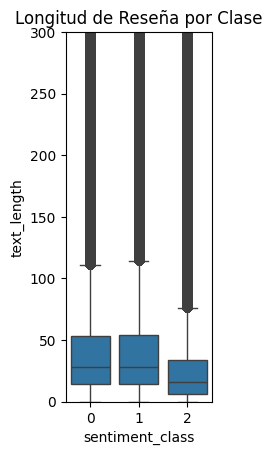

In [51]:
# 2. Boxplot de Longitud de Texto
plt.subplot(1, 3, 2)
sns.boxplot(x='sentiment_class', y='text_length', data=df_final)
plt.ylim(0, 300); plt.title('Longitud de Reseña por Clase')

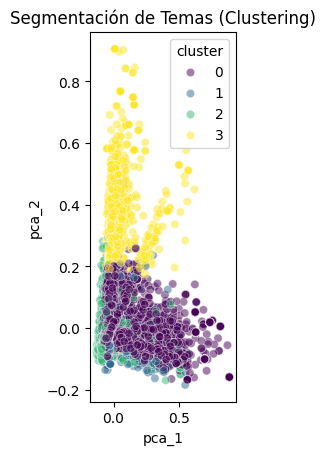

In [52]:
# 3. Visualización de Clusters (Segmentación)
plt.subplot(1, 3, 3)
sns.scatterplot(x='pca_1', y='pca_2', hue='cluster', data=df_cluster, palette='viridis', alpha=0.5)
plt.title('Segmentación de Temas (Clustering)')
plt.show()

☁️ Generando nube de términos frecuentes...


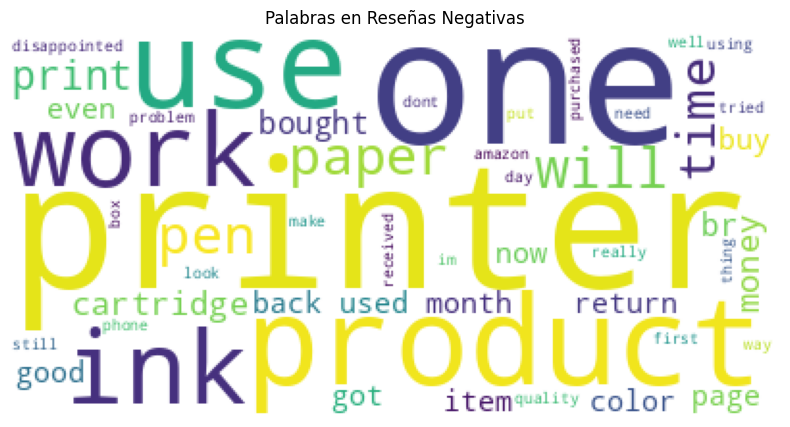

In [53]:
# --- BLOQUE 10: NUBE DE PALABRAS ---
print(" Generando nube de términos frecuentes...")
text_neg = " ".join(df_final[df_final['sentiment_class'] == 0]['text_cleaned'].astype(str).sample(10000))
wc = WordCloud(background_color='white', max_words=50).generate(text_neg)
plt.figure(figsize=(10, 5)); plt.imshow(wc); plt.axis('off'); plt.title('Palabras en Reseñas Negativas'); plt.show()

In [54]:
# --- BLOQUE 11: EXPORTACIÓN (REPRODUCIBILIDAD) ---
print(f" Guardando dataset final en: {OUTPUT_FILE}...")
# Guardamos con compresión para ahorrar espacio en disco
df_final.to_csv(OUTPUT_FILE, index=False, compression='gzip')

print('Notebook 1 completado.')


💾 Guardando dataset final en: data/office_ready_1M.csv.gz...
✅ ¡Notebook 1 Completado Exitosamente!
